In [1]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

In [2]:
from sklearn.datasets import fetch_california_housing

df = fetch_california_housing(as_frame=True)

x = df.data
y = df.target
x[:5]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=TEST_SIZE, random_state=RANDOM_STATE)

model = DecisionTreeRegressor()
model.fit(xtrain, ytrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [4]:
from sklearn.metrics import r2_score

pred = model.predict(xtest)
r2_score(ytest, pred)

0.5731169002446339

In [5]:
pred_train = model.predict(xtrain)
r2_score(ytrain, pred_train)

1.0

Модель переобучилась. Для борьбы с переобучением воспользуемся ограничением по глубине

2 0.4533536295852133 0.4368307487537765
5 0.6492575456637993 0.6027831749910164
8 0.8035977175721698 0.6568958029222507
11 0.9190164092839931 0.609797320532578
14 0.9759463586225111 0.5852633806258416
17 0.9939368812838943 0.5818043679518374
20 0.9984039796010692 0.5741224097161408
23 0.9998339166898758 0.5686632512648042
26 0.999993147358481 0.5620855157744354


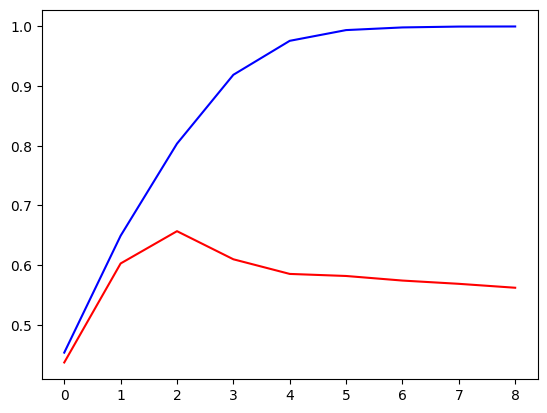

In [6]:
import matplotlib.pyplot as plt
import numpy as np
train_scores = []
test_scores = []

for depth in np.arange(2,27,3):
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(xtrain, ytrain)

    pred_train = model.predict(xtrain)
    pred_test = model.predict(xtest)

    train_r2 = r2_score(ytrain, pred_train)
    test_r2 = r2_score(ytest, pred_test)

    train_scores.append(train_r2)
    test_scores.append(test_r2)

    print(depth, train_r2, test_r2)

plt.plot(train_scores, c='b')
plt.plot(test_scores, c='r')
plt.show()

Оптимальная глубина - 8. Чтобы не привязываться к конкретному разбиению, промерим качество модели на кросс валидации

In [7]:
from sklearn.model_selection import cross_val_score

model = DecisionTreeRegressor(max_depth=8)
cross_val_score(model, x, y, cv=3, scoring='r2')

array([0.47147803, 0.60582595, 0.46888218])

In [8]:
cross_val_score(model, x, y, cv=3, scoring='r2').mean()

np.float64(0.5160452326964549)

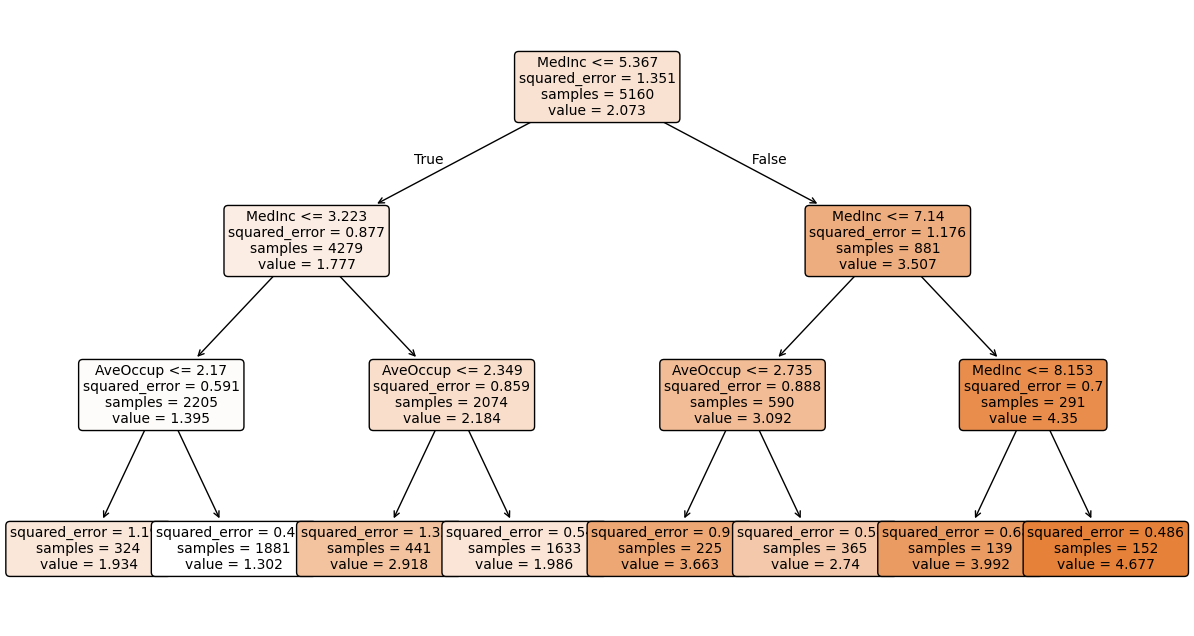

In [16]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

model = DecisionTreeRegressor(max_depth=3)
model.fit(xtrain, ytrain)

plt.figure(figsize=(15, 8))
plot_tree(model, 
          feature_names=xtrain.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()